In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../data/ames_featured.csv")
df.head()

,MS SubClass,Lot Frontage,Street,Lot Shape,Utilities,Land Slope,Overall Qual,Overall Cond,Year Built,Year Remod/Add,...,Garage Type_No Garage,Sale Type_ConLD,Sale Type_New,Sale Type_Other,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,20,141.0,1,3,4,3,6,5,1960,1960.0,...,0,0,0,0,1,0,0,0,1,0
1,20,80.0,1,4,4,3,5,6,1961,1961.0,...,0,0,0,0,1,0,0,0,1,0
2,20,81.0,1,3,4,3,6,6,1958,1958.0,...,0,0,0,0,1,0,0,0,1,0
3,20,93.0,1,4,4,3,7,5,1968,1968.0,...,0,0,0,0,1,0,0,0,1,0
4,60,74.0,1,3,4,3,5,5,1997,1998.0,...,0,0,0,0,1,0,0,0,1,0


In [3]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']
y_log = np.log1p(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train_log = y_log[y_train.index]
y_test_log = y_log[y_test.index]
print(X_train.shape, X_test.shape)

(2344, 137) (586, 137)


In [4]:
corr_matrix = X_train.corr().abs()

# Find pairs above threshold
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if upper.loc[row, col] > 0.85]

high_corr_df = pd.DataFrame(high_corr, columns=['Feature 1', 'Feature 2', 'Correlation'])
print(high_corr_df.sort_values('Correlation', ascending=False))

                     Feature 1             Feature 2  Correlation
5                    House_Age            Year Built     0.999063
15       Garage Type_No Garage         Garage Yr Blt     0.998409
6                    Remod_Age        Year Remod/Add     0.997998
18      Sale Condition_Partial         Sale Type_New     0.984639
9         Exterior 2nd_CmentBd  Exterior 1st_CemntBd     0.982591
12        Exterior 2nd_VinylSd  Exterior 1st_VinylSd     0.978192
11        Exterior 2nd_MetalSd  Exterior 1st_MetalSd     0.970464
4                  Garage Cond           Garage Qual     0.944811
3                  Garage Cond         Garage Yr Blt     0.937208
17       Garage Type_No Garage           Garage Cond     0.933201
2                  Garage Qual         Garage Yr Blt     0.931925
8             Has_Screen_Porch          Screen Porch     0.926664
16       Garage Type_No Garage           Garage Qual     0.925428
10        Exterior 2nd_HdBoard  Exterior 1st_HdBoard     0.898302
1         

In [5]:
drop_cols = [
    # Replaced by age features
    'Year Built', 'Year Remod/Add',
    
    # Replaced by binary flag
    'Screen Porch',
    
    # Exterior 2nd redundant with Exterior 1st
    'Exterior 2nd_CmentBd', 'Exterior 2nd_VinylSd', 'Exterior 2nd_MetalSd',
    'Exterior 2nd_HdBoard', 'Exterior 2nd_Wd Sdng',
    
    # Garage cluster — keep Garage Yr Blt and Garage Cars
    'Garage Qual', 'Garage Cond', 'Garage Area',
    
    # Other redundant pairs
    'Sale Type_New',
    'Fireplaces',
    'Gr Liv Area',
    'BsmtFin Type 2_No Basement'
]

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

print(X_train.shape, X_test.shape)

(2344, 122) (586, 122)


In [6]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)

low_variance = X_train.columns[~selector.get_support()]
print(f"Low variance features: {len(low_variance)}")
print(low_variance.tolist())

Low variance features: 12
['Street', 'Utilities', 'Is_Normal_Cond2', 'MS Zoning_Other', 'Mas Vnr Type_Other', 'Foundation_Stone', 'Foundation_Wood', 'Electrical_Other', 'Garage Type_CarPort', 'Sale Type_ConLD', 'Sale Condition_AdjLand', 'Sale Condition_Alloca']


In [7]:
from sklearn.feature_selection import mutual_info_regression, f_regression

mi_scores = mutual_info_regression(X_train, y_train_log, random_state=42)
f_scores, p_values = f_regression(X_train, y_train_log)

filter_df = pd.DataFrame({
    'MI_Score': mi_scores,
    'F_Score': f_scores,
    'P_Value': p_values
}, index=X_train.columns).sort_values('MI_Score', ascending=False)

print(filter_df.head(20))
print()
print(filter_df.tail(20))

                   MI_Score      F_Score        P_Value
Total_SF           0.615074  3298.235926   0.000000e+00
Overall Qual       0.568728  4736.396833   0.000000e+00
Garage Cars        0.375332  1859.279934  1.585834e-299
Total_Bathrooms    0.364513  1887.334779  6.512453e-303
Total Bsmt SF      0.356923  1361.559997  2.328216e-235
House_Age          0.350095  1309.163903  4.155763e-228
Bsmt Qual          0.348768  1581.271633  1.091806e-264
1st Flr SF         0.327645  1235.291877  1.051275e-217
Garage Yr Blt      0.301295   270.787775   1.161599e-57
Neighborhood_Tier  0.299534  1764.233756  6.982504e-288
Kitchen Qual       0.298685  1740.584100  6.069762e-285
Exter Qual         0.297338  1881.997562  2.859347e-302
MS SubClass        0.286576     5.801242   1.609165e-02
Full Bath          0.261180  1136.728608  1.747381e-203
Remod_Age          0.252159  1121.617637  2.872389e-201
Garage Finish      0.242186  1156.862442  2.018062e-206
2nd Flr SF         0.205039   197.751701   3.507

In [8]:
drop_filter = [
    'Is_Normal_Cond2', 'Mas Vnr Type_Other', 'Foundation_Stone', 'Foundation_Wood',
    'Electrical_Other', 'Garage Type_CarPort', 'Sale Condition_AdjLand',
    'Sale Condition_Alloca', 'Lot Config_FR2', 'BsmtFin Type 2_Rec',
    'BsmtFin Type 2_LwQ', 'BsmtFin Type 2_BLQ', 'Mo Sold',
    'House Style_Other', 'Garage Type_Basment'
]

X_train = X_train.drop(columns=drop_filter)
X_test = X_test.drop(columns=drop_filter)

print(X_train.shape, X_test.shape)

(2344, 107) (586, 107)


In [9]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer

# split features by type
binary_cols = [col for col in X_train.columns if X_train[col].nunique() == 2]
continuous_cols = [col for col in X_train.columns if col not in binary_cols]

print(f"Binary cols: {len(binary_cols)}")
print(f"Continuous cols: {len(continuous_cols)}")

# scale continuous/ordinal
preprocessor = ColumnTransformer(transformers=[
    ('scale', StandardScaler(), continuous_cols),
    ('passthrough', 'passthrough', binary_cols)
])

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(random_state=42, max_iter=10000))
])

alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
param_grid = {'model__alpha': alphas}

grid_search = GridSearchCV(lasso_pipeline, param_grid,
                           cv=5, scoring='neg_mean_squared_error',
                           verbose=1)
grid_search.fit(X_train, y_train_log)

print(f"Best alpha: {grid_search.best_params_['model__alpha']}")
print(f"Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}")

Binary cols: 61
Continuous cols: 46
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best alpha: 0.001
Best CV RMSE: 0.1388


In [10]:
# Evaluate on test set
best_model = grid_search.best_estimator_
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)

# Metrics on log scale
rmse_log = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
r2_log = r2_score(y_test_log, y_pred_log)

# Metrics on original scale
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Test RMSE (log scale): {rmse_log:.4f}")
print(f"Test R² (log scale):   {r2_log:.4f}")
print(f"Test RMSE (original):  ${rmse:,.0f}")
print(f"Test R² (original):    {r2:.4f}")
print(f"Test MAE (original):   ${mae:,.0f}")

lasso_coefs = best_model.named_steps['model'].coef_
print(f"\nFeatures used: {(lasso_coefs != 0).sum()}")
print(f"Features zeroed out: {(lasso_coefs == 0).sum()}")

Test RMSE (log scale): 0.1199
Test R² (log scale):   0.9223
Test RMSE (original):  $33,540
Test R² (original):    0.8597
Test MAE (original):   $16,484

Features used: 56
Features zeroed out: 51


In [11]:
# Get feature names after ColumnTransformer
feature_names = continuous_cols + binary_cols

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_coefs
}).sort_values('Coefficient', key=abs, ascending=False)

print("Top 15 most important features:")
print(coef_df.head(15))
print()
print("Features zeroed out:")
print(coef_df[coef_df['Coefficient'] == 0]['Feature'].tolist())

Top 15 most important features:
                    Feature  Coefficient
5              Overall Qual     0.097322
106  Sale Condition_Partial     0.075963
18               1st Flr SF     0.073813
19               2nd Flr SF     0.066695
47              Central Air     0.061938
105   Sale Condition_Normal     0.060819
43             Lot Area_log     0.044281
48         Has_Screen_Porch     0.042661
6              Overall Cond     0.040971
45        Neighborhood_Tier    -0.035992
41                 Total_SF     0.032685
52          Is_Normal_Cond1     0.029615
39                House_Age    -0.029313
32              Garage Cars     0.029188
54             MS Zoning_FV     0.028146

Features zeroed out:
['Exterior 1st_WdShing', 'Exterior 1st_Wd Sdng', 'Exterior 2nd_Other', 'Exterior 2nd_Plywood', 'Exterior 2nd_Wd Shng', 'Exterior 1st_VinylSd', 'Mas Vnr Type_None', 'Mas Vnr Type_Stone', 'Foundation_CBlock', 'Street', 'Foundation_Slab', 'Exterior 1st_Plywood', 'BsmtFin Type 2_Unf', 'Electri

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}

grid_search_rf = GridSearchCV(rf_pipeline, param_grid_rf,
                              cv=5, scoring='neg_mean_squared_error',
                              verbose=1, n_jobs=-1)
grid_search_rf.fit(X_train, y_train_log)

print(f"Best params: {grid_search_rf.best_params_}")
print(f"Best CV RMSE: {np.sqrt(-grid_search_rf.best_score_):.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV RMSE: 0.1390


In [13]:
best_rf = grid_search_rf.best_estimator_
y_pred_rf_log = best_rf.predict(X_test)
y_pred_rf = np.expm1(y_pred_rf_log)

# Metrics on log scale
rmse_rf_log = np.sqrt(mean_squared_error(y_test_log, y_pred_rf_log))
r2_rf_log = r2_score(y_test_log, y_pred_rf_log)

# Metrics on original scale
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Test RMSE (log scale): {rmse_rf_log:.4f}")
print(f"Test R² (log scale):   {r2_rf_log:.4f}")
print(f"Test RMSE (original):  ${rmse_rf:,.0f}")
print(f"Test R² (original):    {r2_rf:.4f}")
print(f"Test MAE (original):   ${mae_rf:,.0f}")

# Compare both models
print("\n── Model Comparison ──────────────────────────────")
print(f"{'':20} {'Lasso':>10} {'RF':>10}")
print(f"{'RMSE (log)':20} {rmse_log:>10.4f} {rmse_rf_log:>10.4f}")
print(f"{'R² (log)':20} {r2_log:>10.4f} {r2_rf_log:>10.4f}")
print(f"{'RMSE (original)':20} ${rmse:>9,.0f} ${rmse_rf:>9,.0f}")
print(f"{'R² (original)':20} {r2:>10.4f} {r2_rf:>10.4f}")
print(f"{'MAE (original)':20} ${mae:>9,.0f} ${mae_rf:>9,.0f}")

Test RMSE (log scale): 0.1199
Test R² (log scale):   0.9224
Test RMSE (original):  $24,754
Test R² (original):    0.9236
Test MAE (original):   $15,507

── Model Comparison ──────────────────────────────
                          Lasso         RF
RMSE (log)               0.1199     0.1199
R² (log)                 0.9223     0.9224
RMSE (original)      $   33,540 $   24,754
R² (original)            0.8597     0.9236
MAE (original)       $   16,484 $   15,507


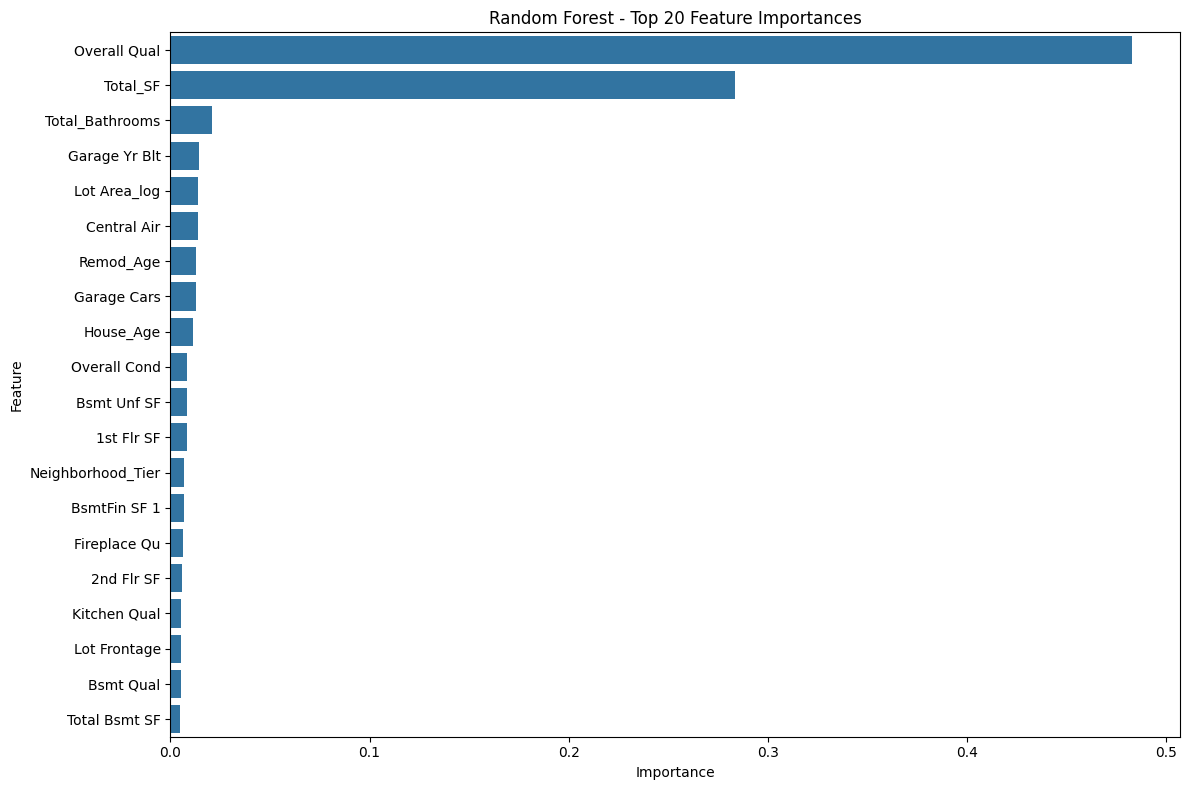

              Feature  Importance
6        Overall Qual    0.482675
43           Total_SF    0.283672
44    Total_Bathrooms    0.020924
32      Garage Yr Blt    0.014222
47       Lot Area_log    0.013699
19        Central Air    0.013658
42          Remod_Age    0.012839
34        Garage Cars    0.012785
41          House_Age    0.011542
7        Overall Cond    0.008454
16        Bsmt Unf SF    0.008165
20         1st Flr SF    0.008120
49  Neighborhood_Tier    0.006926
15       BsmtFin SF 1    0.006600
31       Fireplace Qu    0.006111
21         2nd Flr SF    0.005665
28       Kitchen Qual    0.005441
1        Lot Frontage    0.005241
11          Bsmt Qual    0.005211
17      Total Bsmt SF    0.004621


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = best_rf.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(20), x='Importance', y='Feature')
plt.title('Random Forest - Top 20 Feature Importances')
plt.tight_layout()
plt.show()

print(importance_df.head(20))

In [15]:
from xgboost import XGBRegressor

xgb_pipeline = Pipeline([
    ('model', XGBRegressor(random_state=42, n_jobs=-1, verbosity=0))
])

param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(xgb_pipeline, param_grid_xgb,
                               cv=5, scoring='neg_mean_squared_error',
                               verbose=1, n_jobs=-1)
grid_search_xgb.fit(X_train, y_train_log)

print(f"Best params: {grid_search_xgb.best_params_}")
print(f"Best CV RMSE: {np.sqrt(-grid_search_xgb.best_score_):.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best CV RMSE: 0.1245


In [16]:
best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb_log = best_xgb.predict(X_test)
y_pred_xgb = np.expm1(y_pred_xgb_log)

# Metrics
rmse_xgb_log = np.sqrt(mean_squared_error(y_test_log, y_pred_xgb_log))
r2_xgb_log = r2_score(y_test_log, y_pred_xgb_log)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print(f"Test RMSE (log scale): {rmse_xgb_log:.4f}")
print(f"Test R² (log scale):   {r2_xgb_log:.4f}")
print(f"Test RMSE (original):  ${rmse_xgb:,.0f}")
print(f"Test R² (original):    {r2_xgb:.4f}")
print(f"Test MAE (original):   ${mae_xgb:,.0f}")

# Three-way comparison
print(f"{'':20} {'Lasso':>10} {'RF':>10} {'XGBoost':>10}")
print(f"{'RMSE (log)':20} {rmse_log:>10.4f} {rmse_rf_log:>10.4f} {rmse_xgb_log:>10.4f}")
print(f"{'R² (log)':20} {r2_log:>10.4f} {r2_rf_log:>10.4f} {r2_xgb_log:>10.4f}")
print(f"{'RMSE (original)':20} ${rmse:>9,.0f} ${rmse_rf:>9,.0f} ${rmse_xgb:>9,.0f}")
print(f"{'R² (original)':20} {r2:>10.4f} {r2_rf:>10.4f} {r2_xgb:>10.4f}")
print(f"{'MAE (original)':20} ${mae:>9,.0f} ${mae_rf:>9,.0f} ${mae_xgb:>9,.0f}")

Test RMSE (log scale): 0.1048
Test R² (log scale):   0.9406
Test RMSE (original):  $22,947
Test R² (original):    0.9343
Test MAE (original):   $14,080
                          Lasso         RF    XGBoost
RMSE (log)               0.1199     0.1199     0.1048
R² (log)                 0.9223     0.9224     0.9406
RMSE (original)      $   33,540 $   24,754 $   22,947
R² (original)            0.8597     0.9236     0.9343
MAE (original)       $   16,484 $   15,507 $   14,080


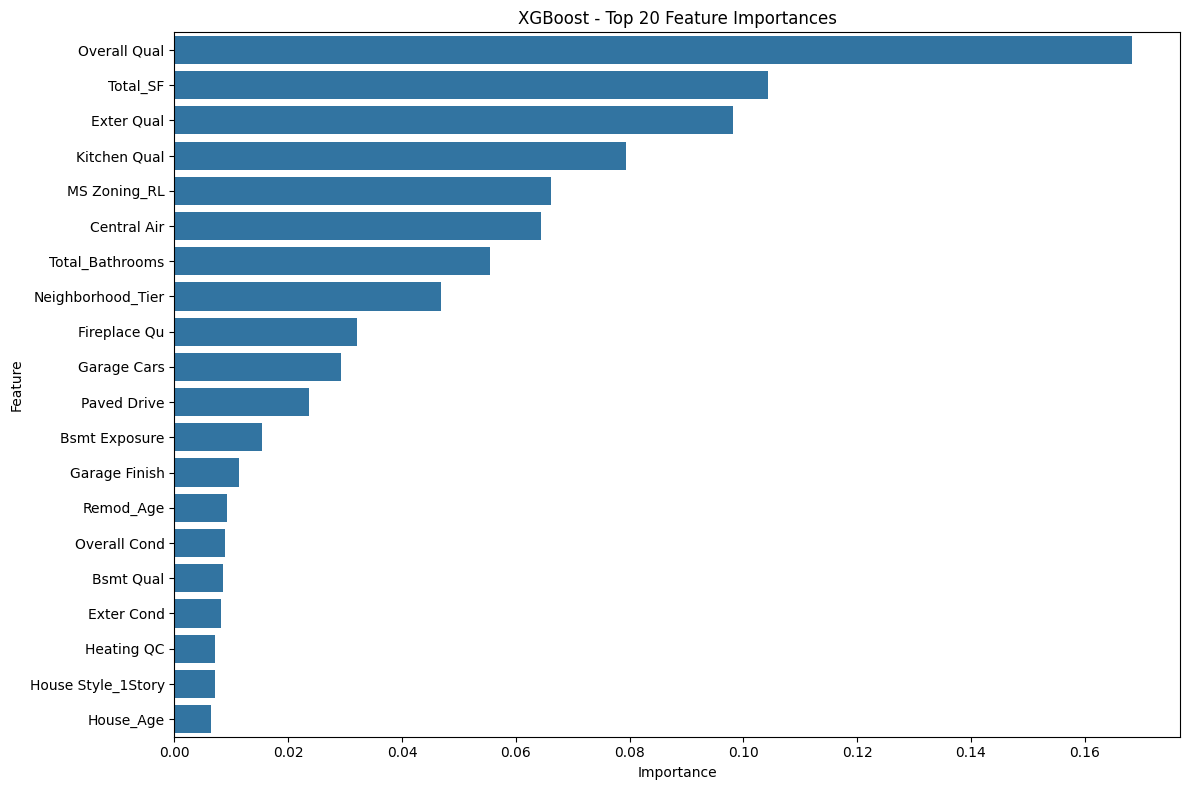

               Feature  Importance
6         Overall Qual    0.168323
43            Total_SF    0.104284
9           Exter Qual    0.098219
28        Kitchen Qual    0.079294
57        MS Zoning_RL    0.066128
19         Central Air    0.064359
44     Total_Bathrooms    0.055474
49   Neighborhood_Tier    0.046857
31        Fireplace Qu    0.032037
34         Garage Cars    0.029243
35         Paved Drive    0.023653
13       Bsmt Exposure    0.015464
33       Garage Finish    0.011420
42           Remod_Age    0.009280
7         Overall Cond    0.008886
11           Bsmt Qual    0.008592
10          Exter Cond    0.008218
18          Heating QC    0.007210
70  House Style_1Story    0.007165
41           House_Age    0.006427


In [17]:
xgb_importances = best_xgb.named_steps['model'].feature_importances_

xgb_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=xgb_importance_df.head(20), x='Importance', y='Feature')
plt.title('XGBoost - Top 20 Feature Importances')
plt.tight_layout()
plt.show()

print(xgb_importance_df.head(20))

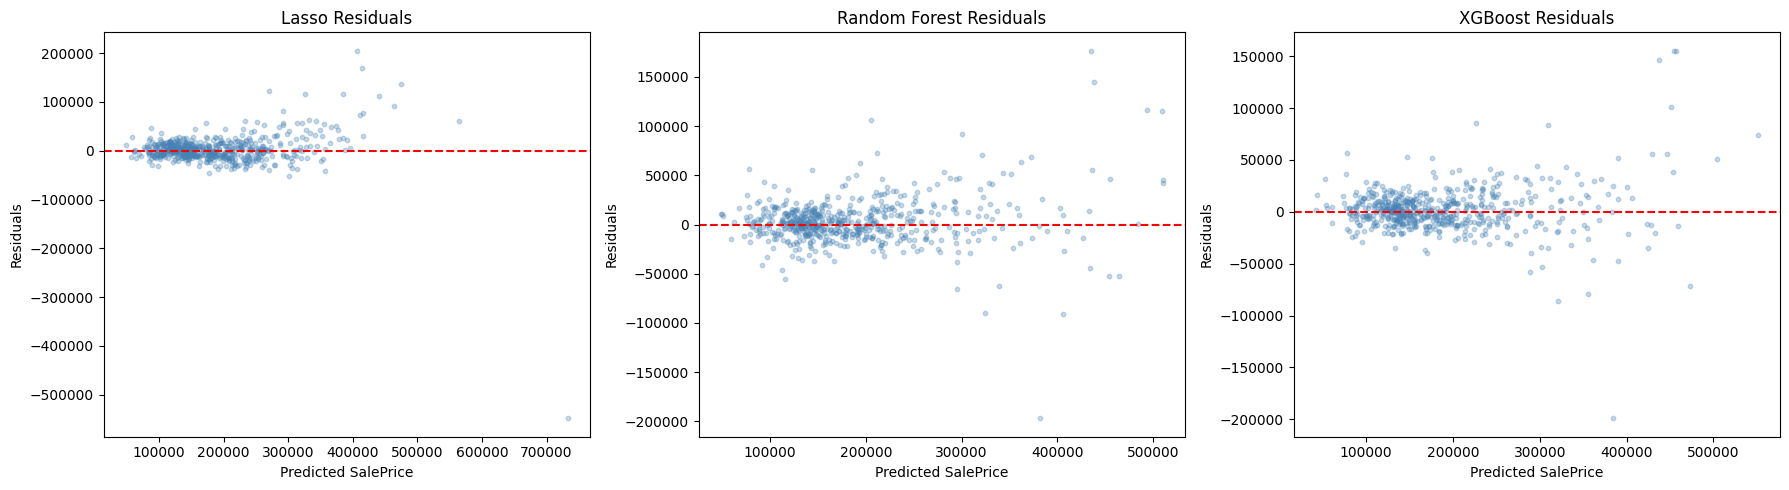

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = {
    'Lasso': (y_pred, y_test),
    'Random Forest': (y_pred_rf, y_test),
    'XGBoost': (y_pred_xgb, y_test)
}

for ax, (name, (y_pred_model, y_actual)) in zip(axes, models.items()):
    residuals = y_actual - y_pred_model
    ax.scatter(y_pred_model, residuals, alpha=0.3, color='steelblue', s=10)
    ax.axhline(y=0, color='red', linestyle='--')
    ax.set_xlabel('Predicted SalePrice')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{name} Residuals')

plt.tight_layout()
plt.show()